# NYC Airbnb Data Analysis

## Data Loading and Initial Inspection

This notebook begins the exploratory data analysis (EDA) of the NYC Airbnb Open Data dataset.

The objectives of this notebook are to:

- Load the dataset into a pandas DataFrame.
- Inspect the structure of the data.
- Understand the available features.
- Identify potential data quality issues.
- Define the next steps for data cleaning.

## Import Libraries

Import the libraries required for data loading and file management.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

## Define Project Paths




In [ ]:
PROJECT_ROOT = Path.cwd().parent
RAW_DATA = PROJECT_ROOT/'data'/'raw'
PROCESSED_DATA = PROJECT_ROOT/'data'/'processed'


## Load and inspect the Dataset



In [ ]:
df = pd.read_csv(RAW_DATA/'AB_NYC_2019.csv')
print('Dataset shape:', df.shape)



Dataset shape: (48895, 16)
Dataset size: 782320



## Display the First Records

Display the first few rows to gain an initial understanding of the dataset and verify that the columns have been imported correctly.

In [19]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [25]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [26]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [34]:
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [44]:
df.duplicated().sum()

np.int64(0)

## Checking for outliers

In [46]:
df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365


In [50]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

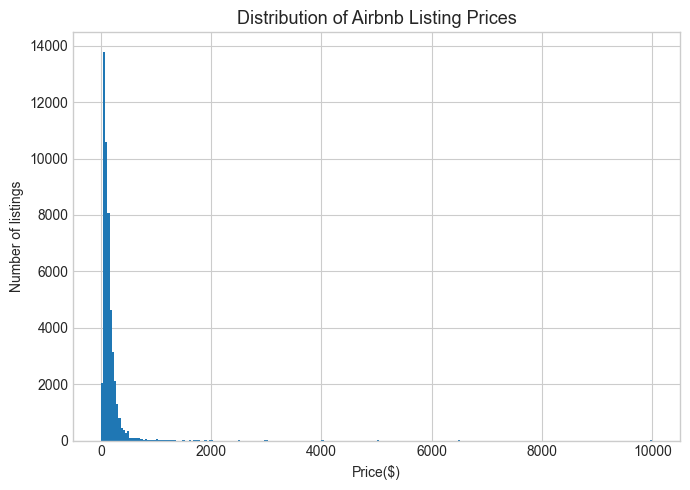

In [145]:
fig,ax = plt.subplots(figsize =(7,5))
df['price'].plot.hist(bins = 250, ax = ax)
plt.xlabel('Price($)')
plt.ylabel('Number of listings')
plt.title("Distribution of Airbnb Listing Prices", fontsize = 13)
plt.savefig(PROJECT_ROOT/'images'/'prices_histogram_plot.png', dpi = 300)
plt.tight_layout()
plt.show()

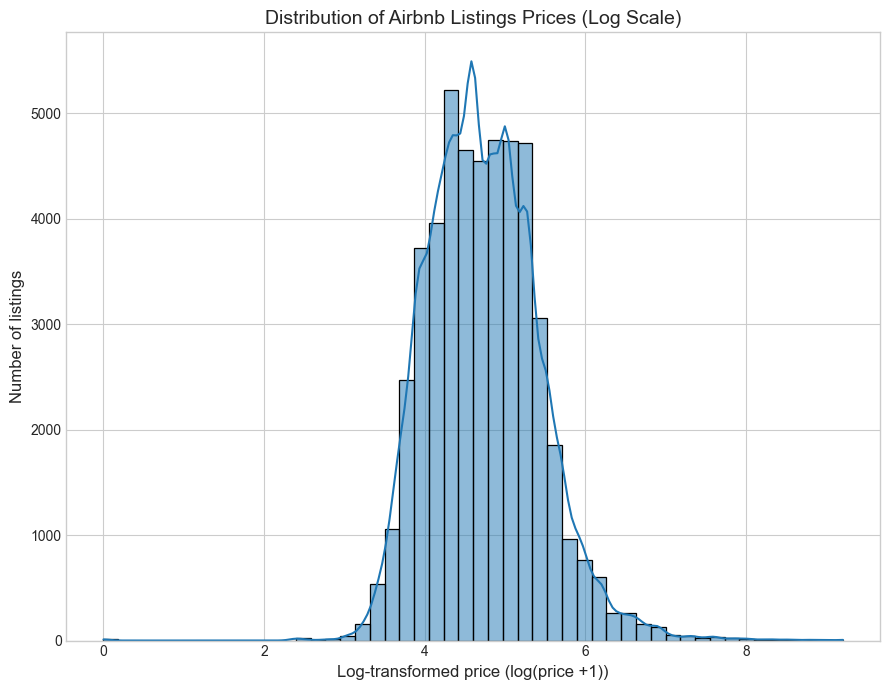

In [146]:
df['log_price'] = np.log1p(df['price'])

#Visualizing the log_price column to see the distribution more clearly
fig,ax = plt.subplots(figsize =(9,7))
sns.histplot(df, x= 'log_price', bins = 50, ax = ax ,kde = True)
plt.xlabel('Log-transformed price (log(price +1))', fontsize = '12')
plt.ylabel('Number of listings', fontsize = '12')
plt.title("Distribution of Airbnb Listings Prices (Log Scale)", fontsize = 14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT/'images'/'Log_prices_histogram_plot.png', dpi = 300)
plt.show()

## Price Outliers

The price variable contains a large number of extreme values compared to the majority of listings.

These observations should not automatically be removed because high prices may represent legitimate luxury properties or unique accommodations.

Further investigation is required to determine whether extreme values are:
- valid high-end listings,
- data entry errors,
- or unrealistic values that could influence analysis.

In [158]:
df['neighbourhood'].value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

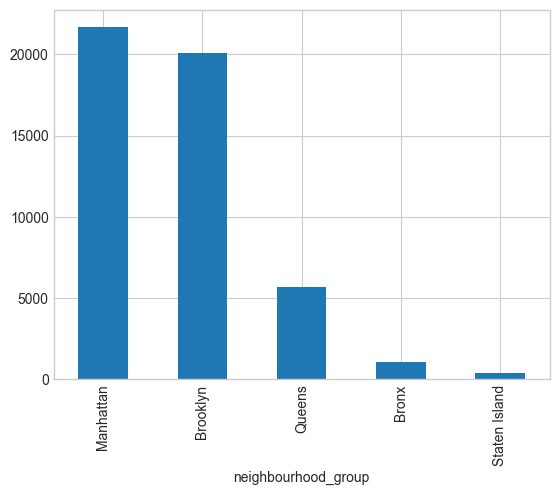

In [170]:
df['neighbourhood_group'].value_counts().plot.bar()
plt.show()

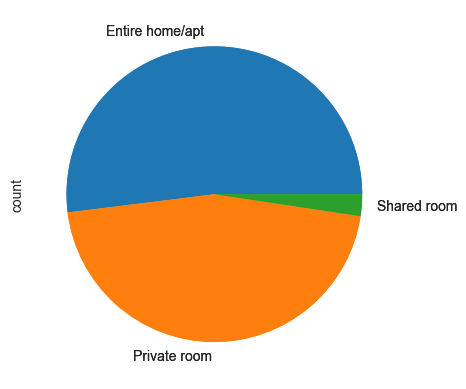

In [186]:
df['room_type'].value_counts().plot.pie()
plt.show()

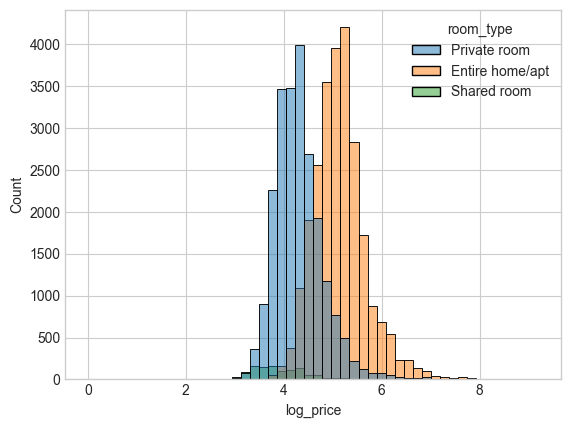

In [191]:
sns.histplot(df, x = 'log_price', hue = 'room_type', bins = 50)
plt.show()

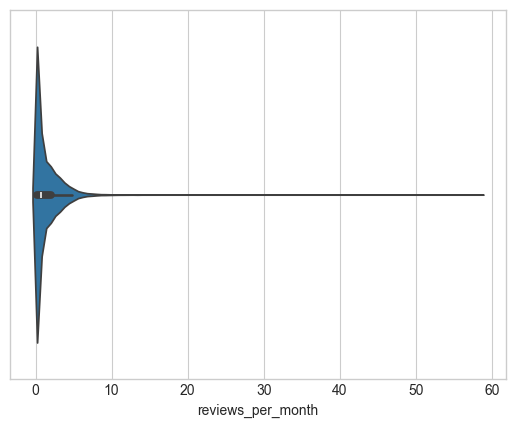

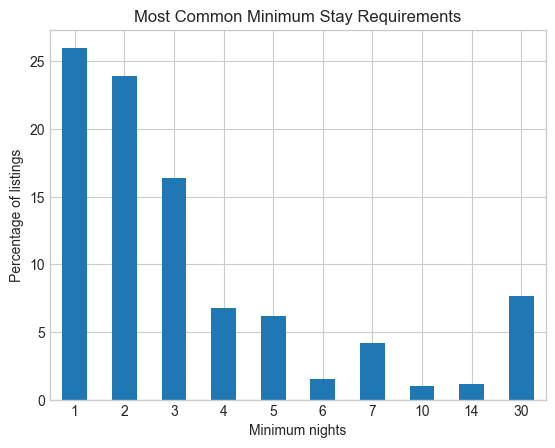

In [229]:
(
    df["minimum_nights"]
      .value_counts(normalize=True)
      .mul(100)
      .nlargest(10)
      .sort_index()
      .plot.bar()
)

plt.ylabel("Percentage of listings")
plt.xlabel("Minimum nights")
plt.xticks(rotation = 0)
plt.title("Most Common Minimum Stay Requirements")
plt.show()
